### Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

For starters, let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

In [1]:
import sys, os
#if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
#    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
#    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week02_value_based/mdp.py
#    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
#if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
#    !bash ../xvfb start
#    os.environ['DISPLAY'] = ':1'

In [2]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


We can now use MDP just as any other gym environment:

In [3]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


but it also has other methods that you'll need for Value Iteration

In [4]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. 

1. * For ubuntu just run: `sudo apt-get install graphviz` 
   * For OSX: `brew install graphviz`
2. `pip install graphviz`
3. restart the notebook

__Note:__ Installing graphviz on some OS (esp. Windows) may be tricky. However, you can ignore this part alltogether and use the standart vizualization.

In [5]:
from mdp import has_graphviz
from IPython.display import display
print("Graphviz available:", has_graphviz)

Graphviz available: False


In [6]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

### Value Iteration

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^{\pi}$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [7]:
def get_action_value(mdp, state_values, state, action, gamma):
    """ Computes Q(s,a) as in formula above """

    Q = 0
    for next_state, prob in mdp.get_next_states(state, action).items():
        reward = mdp.get_reward(state, action, next_state)
        Q += prob * (reward + gamma * state_values[next_state])
    return Q

In [8]:
import numpy as np
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [9]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Computes next V(s) as in formula above. Please do not change state_values in process. """
    if mdp.is_terminal(state):
        return 0
    
    return max(get_action_value(mdp, state_values, state, a, gamma) 
               for a in mdp.get_possible_actions(state))

In [10]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert test_Vs == test_Vs_copy, "Please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

In [11]:
# parameters
gamma = 0.9            # discount for MDP
num_iter = 100         # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    new_state_values = {}
    for s in mdp.get_all_states():
        new_state_values[s] = get_new_state_value(mdp, state_values, s, gamma) 

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print('   '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

iter    0   |   diff: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
iter    1   |   diff: 0.64500   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = 0.000
iter    2   |   diff: 0.58050   |   V(s0) = 0.000   V(s1) = 3.815   V(s2) = 0.645
iter    3   |   diff: 0.43582   |   V(s0) = 0.581   V(s1) = 3.959   V(s2) = 0.962
iter    4   |   diff: 0.30634   |   V(s0) = 0.866   V(s1) = 4.395   V(s2) = 1.272
iter    5   |   diff: 0.27571   |   V(s0) = 1.145   V(s1) = 4.670   V(s2) = 1.579
iter    6   |   diff: 0.24347   |   V(s0) = 1.421   V(s1) = 4.926   V(s2) = 1.838
iter    7   |   diff: 0.21419   |   V(s0) = 1.655   V(s1) = 5.169   V(s2) = 2.075
iter    8   |   diff: 0.19277   |   V(s0) = 1.868   V(s1) = 5.381   V(s2) = 2.290
iter    9   |   diff: 0.17327   |   V(s0) = 2.061   V(s1) = 5.573   V(s2) = 2.481
iter   10   |   diff: 0.15569   |   V(s0) = 2.233   V(s1) = 5.746   V(s2) = 2.654
iter   11   |   diff: 0.14012   |   V(s0) = 2.389   V(s1) = 5.902   V(s2) = 2.810
iter   12   |   

In [12]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [13]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.294006423867229, 's2': 4.202140275227048}


Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = argmax_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = argmax_a Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [14]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """ Finds optimal action using formula above. """
    if mdp.is_terminal(state):
        return None

    q_values = {action: get_action_value(mdp, state_values, state, action, gamma)
                for action in mdp.get_possible_actions(state)}
    return max(q_values, key=q_values.get)

In [15]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"

In [16]:
if has_graphviz:
    display(plot_graph_optimal_strategy_and_state_values(mdp, state_values, get_action_value))

In [17]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4641


### Frozen lake

In [18]:
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [19]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):

        # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
        new_state_values = {}
        for s in mdp.get_all_states():
            new_state_values[s] = get_new_state_value(mdp, state_values, s, gamma)


        assert isinstance(new_state_values, dict)

        # Compute difference
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [20]:
state_values = value_iteration(mdp)

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 


In [21]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
iter    0   |   diff: 1.00000   |   V(start): 0.000 


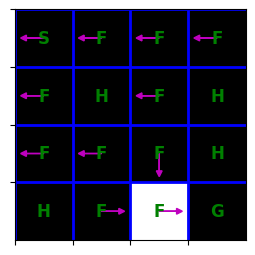

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 0.000 


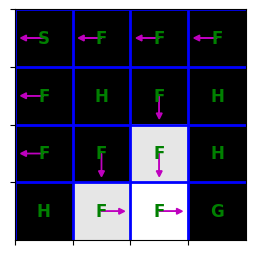

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 0.000 


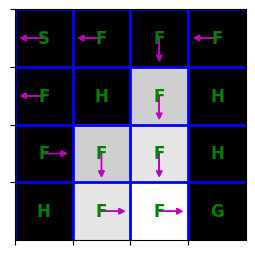

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 0.000 


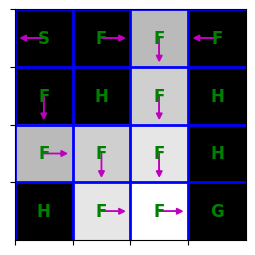

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 0.000 


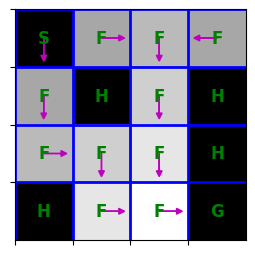

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 0.590 


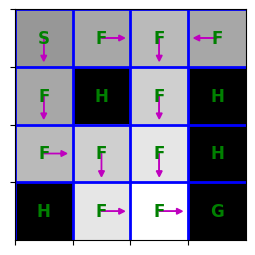

after iteration 6
iter    0   |   diff: 0.00000   |   V(start): 0.590 


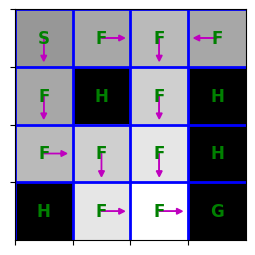

after iteration 7
iter    0   |   diff: 0.00000   |   V(start): 0.590 


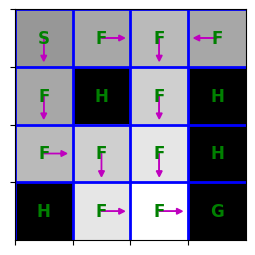

after iteration 8
iter    0   |   diff: 0.00000   |   V(start): 0.590 


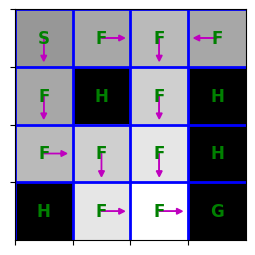

after iteration 9
iter    0   |   diff: 0.00000   |   V(start): 0.590 


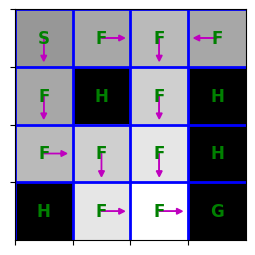

In [23]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 29
iter    0   |   diff: 0.00000   |   V(start): 0.198 


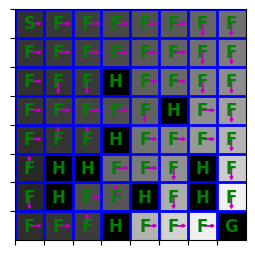

In [24]:
from IPython.display import clear_output
from time import sleep
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [25]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
average reward:  1.0
Well done!


In [26]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
average reward:  0.878
Well done!


In [27]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

iter    0   |   diff: 0.75000   |   V(start): 0.000 
iter    1   |   diff: 0.50625   |   V(start): 0.000 
iter    2   |   diff: 0.39867   |   V(start): 0.000 
iter    3   |   diff: 0.26910   |   V(start): 0.000 
iter    4   |   diff: 0.18164   |   V(start): 0.000 
iter    5   |   diff: 0.14013   |   V(start): 0.140 
iter    6   |   diff: 0.07028   |   V(start): 0.199 
iter    7   |   diff: 0.06030   |   V(start): 0.260 
iter    8   |   diff: 0.02594   |   V(start): 0.285 
iter    9   |   diff: 0.01918   |   V(start): 0.305 
iter   10   |   diff: 0.00858   |   V(start): 0.313 
iter   11   |   diff: 0.00560   |   V(start): 0.319 
iter   12   |   diff: 0.00260   |   V(start): 0.321 
iter   13   |   diff: 0.00159   |   V(start): 0.323 
iter   14   |   diff: 0.00076   |   V(start): 0.324 
iter   15   |   diff: 0.00045   |   V(start): 0.324 
iter   16   |   diff: 0.00022   |   V(start): 0.324 
iter   17   |   diff: 0.00012   |   V(start): 0.325 
iter   18   |   diff: 0.00006   |   V(start): 

In [28]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 0.058 
iter   15   |   diff: 0.02910   |   V(start): 0.087 
iter   16   |   diff: 0.01855   |   V(start): 0.106 
iter   17   |   diff: 0.01403   |   V(start): 0.120 
iter   18   |   diff: 0.00810   |   V(start): 

# HW Part 1: Value iteration convergence

### Find an MDP for which value iteration takes long to converge  (1 pts)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6--i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions--we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here--you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

In [29]:
transition_probs = {
    's0': {'a0': {'s0': 1.0}, 'a1': {'s1': 1.0}},
    's1': {'a0': {'s1': 0.96, 's2': 0.04}, 'a1': {'s1': 1.0}},
    's2': {'a0': {'s2': 1.0}, 'a1': {'s2': 1.0}}
}
rewards = {
    's2': {'a0': {'s2': 1000}}
}
from mdp import MDP
from numpy import random
mdp = MDP(transition_probs, rewards, initial_state=random.choice(tuple(transition_probs.keys())))
# Feel free to change the initial_state

In [30]:
state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

for i in range(100):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    n_changes = (policy != new_policy).sum()
    print("N actions changed = %i \n" % n_changes)
    policy = new_policy

# please ignore iter 0 at each step

after iteration 0
iter    0   |   diff: 1000.00000   |   V(start): 1000.000 
N actions changed = 0 

after iteration 1
iter    0   |   diff: 900.00000   |   V(start): 1900.000 
N actions changed = 1 

after iteration 2
iter    0   |   diff: 810.00000   |   V(start): 2710.000 
N actions changed = 0 

after iteration 3
iter    0   |   diff: 729.00000   |   V(start): 3439.000 
N actions changed = 0 

after iteration 4
iter    0   |   diff: 656.10000   |   V(start): 4095.100 
N actions changed = 0 

after iteration 5
iter    0   |   diff: 590.49000   |   V(start): 4685.590 
N actions changed = 0 

after iteration 6
iter    0   |   diff: 531.44100   |   V(start): 5217.031 
N actions changed = 0 

after iteration 7
iter    0   |   diff: 478.29690   |   V(start): 5695.328 
N actions changed = 0 

after iteration 8
iter    0   |   diff: 430.46721   |   V(start): 6125.795 
N actions changed = 0 

after iteration 9
iter    0   |   diff: 387.42049   |   V(start): 6513.216 
N actions changed = 0 


### Value iteration convervence proof (1 pts)
**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

Update of value function in value iteration can be rewritten in a form of Bellman operator:

$$(TV)(s) = \max_{a \in \mathcal{A}}\mathbb{E}\left[ r_{t+1} + \gamma V(s_{t+1}) | s_t = s, a_t = a\right]$$

Value iteration algorithm with Bellman operator:

---
&nbsp;&nbsp; Initialize $V_0$

&nbsp;&nbsp; **for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; $V_{k+1} \leftarrow TV_k$

&nbsp;&nbsp;**end for**

---

In [lecture](https://docs.google.com/presentation/d/1lz2oIUTvd2MHWKEQSH8hquS66oe4MZ_eRvVViZs2uuE/edit#slide=id.g4fd6bae29e_2_4) we established contraction property of bellman operator:

$$
||TV - TU||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

Using contraction property of Bellman operator, Banach fixed-point theorem and Bellman equations prove that value function converges to $V^*$ in value iterateion$

*<-- Your proof here -->*

### Asynchronious value iteration (2 pts)

Consider the following algorithm:

---

Initialize $V_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Select some state $s_k \in \mathcal{S}$    

&nbsp;&nbsp;&nbsp;&nbsp; $V(s_k) := (TV)(s_k)$

**end for**

---


Note that unlike common value iteration, here we update only a single state at a time.

**Homework.** Prove the following proposition:

If for all $s \in \mathcal{S}$, $s$ appears in the sequence $(s_0, s_1, ...)$ infinitely often, then $V$ converges to $V*$

*<-- Your proof here -->*


# HW Part 2: Policy iteration

## Policy iteration implementateion (3 pts)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \operatorname*{argmax}_a Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [31]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's1': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve`.)

In [32]:
def compute_vpi(mdp, policy, gamma):
    """
    Computes V^pi(s) FOR ALL STATES under given policy by solving the linear system.
    Использует методы mdp, определенные в классе MDP.
    """
    states = list(mdp.get_all_states())
    n = len(states)
    state_to_idx = {s: i for i, s in enumerate(states)}
    
    # Build the linear system A * V = b
    # V(s) = sum_s' P(s'|s, pi(s)) * [R(s, pi(s), s') + gamma * V(s')]
    # V(s) - gamma * sum_s' P(s'|s, pi(s)) * V(s') = sum_s' P(s'|s, pi(s)) * R(s, pi(s), s')
    
    A = np.zeros((n, n))
    b = np.zeros(n)
    
    for s in states:
        i = state_to_idx[s]
        A[i, i] = 1.0  # V(s) term
        
        if mdp.is_terminal(s):
            continue
            
        action = policy[s]
        if action is None:
            continue
            
        next_states_probs = mdp.get_next_states(s, action)
        
        for next_s, prob in next_states_probs.items():
            j = state_to_idx[next_s]
            reward = mdp.get_reward(s, action, next_s)
            
            # Move gamma * P * V(s') to the left side
            A[i, j] -= gamma * prob
            b[i] += prob * reward
            
    # Solve the system
    V_values = np.linalg.solve(A, b)
    
    return {s: V_values[state_to_idx[s]] for s in states}

In [33]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

{'s0': np.float64(3.789948615114679), 's1': np.float64(7.3029201654342675), 's2': np.float64(4.211054016794088)}


Once we've got new state values, it's time to update our policy.

In [34]:
def compute_new_policy(mdp, vpi, gamma):
    """
    Computes new policy as argmax of state values
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """
    new_policy = {}
    for s in mdp.get_all_states():
        if mdp.is_terminal(s):
            new_policy[s] = None
        else:
            # Используем готовую функцию из семинара
            new_policy[s] = get_optimal_action(mdp, vpi, s, gamma)
    return new_policy

In [35]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

{'s0': 'a1', 's1': 'a0', 's2': 'a0'}


__Main loop__

In [36]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ 
    Run the policy iteration loop for num_iter iterations or till difference between V(s) is below min_difference.
    If policy is not given, initialize it at random.
    """
    if policy is None:
        policy = {}
        for s in mdp.get_all_states():
            if mdp.is_terminal(s):
                policy[s] = None
            else:
                possible_actions = mdp.get_possible_actions(s)
                policy[s] = possible_actions[0] if possible_actions else None

    for i in range(num_iter):
        # 1. Policy Evaluation: Compute V_pi exactly
        state_values = compute_vpi(mdp, policy, gamma)
        
        # 2. Policy Improvement: Compute new greedy policy
        new_policy = compute_new_policy(mdp, state_values, gamma)
        
        # Check for convergence (policy stability)
        if new_policy == policy:
            break
            
        policy = new_policy
        
    return state_values, policy

__Your PI Results__

=== Custom MDP ===


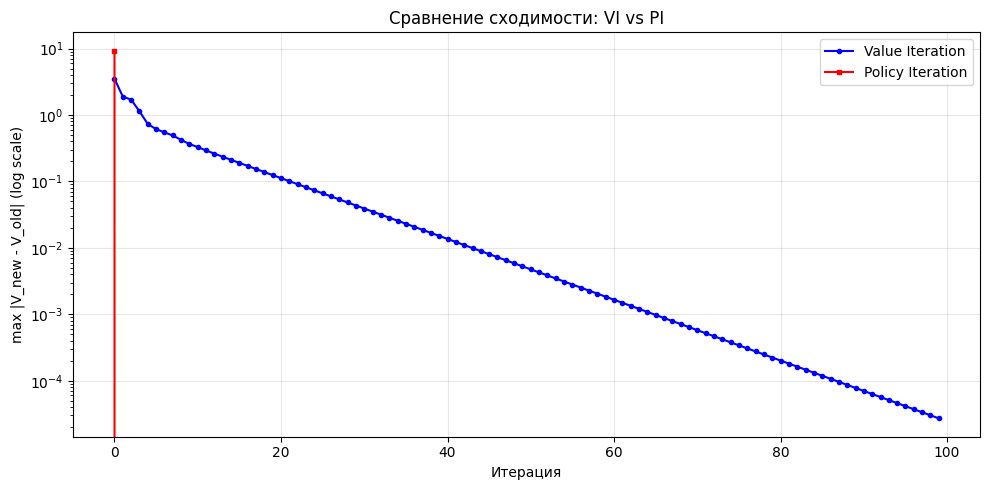

VI: 100 итераций до сходимости
PI: 2 итераций до сходимости

=== Timing comparison ===
iter    0   |   diff: 3.50000   |   V(start): 0.000 
iter    1   |   diff: 1.89000   |   V(start): 0.000 
iter    2   |   diff: 1.70100   |   V(start): 1.701 
iter    3   |   diff: 1.13542   |   V(start): 1.854 
iter    4   |   diff: 0.73024   |   V(start): 2.584 
iter    5   |   diff: 0.61135   |   V(start): 3.186 
iter    6   |   diff: 0.54664   |   V(start): 3.590 
iter    7   |   diff: 0.49198   |   V(start): 4.082 
iter    8   |   diff: 0.42210   |   V(start): 4.463 
iter    9   |   diff: 0.36513   |   V(start): 4.816 
iter   10   |   diff: 0.32862   |   V(start): 5.145 
iter   11   |   diff: 0.29262   |   V(start): 5.429 
iter   12   |   diff: 0.26189   |   V(start): 5.691 
iter   13   |   diff: 0.23503   |   V(start): 5.925 
iter   14   |   diff: 0.21124   |   V(start): 6.135 
iter   15   |   diff: 0.19012   |   V(start): 6.325 
iter   16   |   diff: 0.17091   |   V(start): 6.496 
iter   17   

/tmp/ipykernel_33083/59378221.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([vi_times, pi_times], labels=['Value Iteration', 'Policy Iteration'])


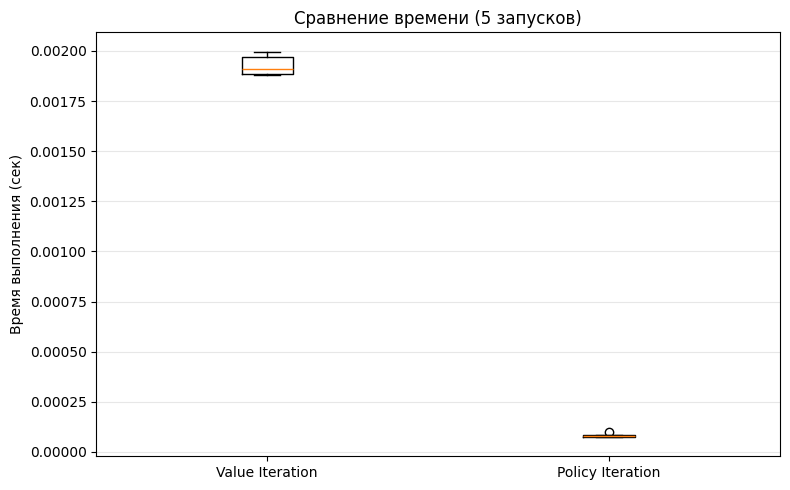

VI: среднее 1.93 мс ± 0.05 мс
PI: среднее 0.08 мс ± 0.01 мс

=== FrozenLake comparison ===
iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
Политики

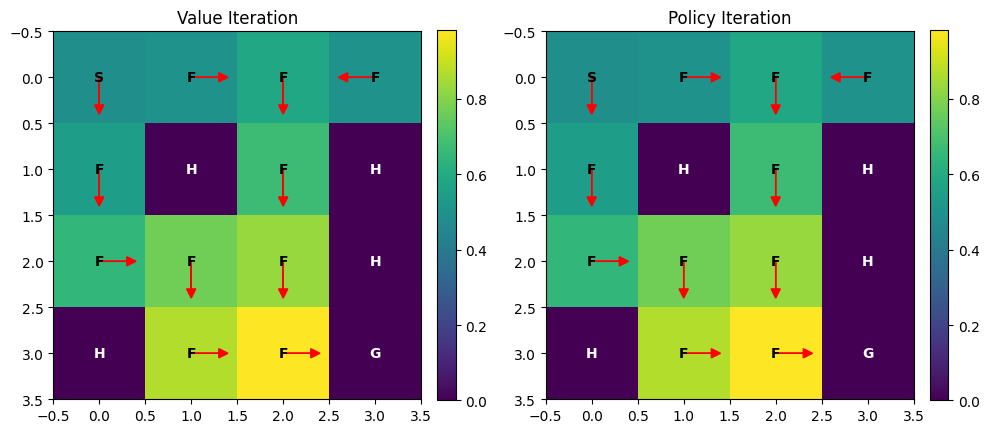

({(0, 0): 'down',
  (0, 1): 'right',
  (0, 2): 'down',
  (0, 3): 'left',
  (1, 0): 'down',
  (1, 1): None,
  (1, 2): 'down',
  (1, 3): None,
  (2, 0): 'right',
  (2, 1): 'down',
  (2, 2): 'down',
  (2, 3): None,
  (3, 0): None,
  (3, 1): 'right',
  (3, 2): 'right',
  (3, 3): None},
 {(0, 0): 'down',
  (0, 1): 'right',
  (0, 2): 'down',
  (0, 3): 'left',
  (1, 0): 'down',
  (1, 1): None,
  (1, 2): 'down',
  (1, 3): None,
  (2, 0): 'right',
  (2, 1): 'down',
  (2, 2): 'down',
  (2, 3): None,
  (3, 0): None,
  (3, 1): 'right',
  (3, 2): 'right',
  (3, 3): None})

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from time import time

# === 1. Сравнение сходимости по итерациям ===
def compare_convergence(mdp, gamma=0.9, max_iter=100):
    """Сравнивает сходимость VI и PI по итерациям"""
    
    # Value Iteration: отслеживаем diff по итерациям
    vi_diffs = []
    state_values = {s: 0 for s in mdp.get_all_states()}
    for i in range(max_iter):
        new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma) 
                           for s in mdp.get_all_states()}
        diff = max(abs(new_state_values[s] - state_values[s]) 
                  for s in mdp.get_all_states())
        vi_diffs.append(diff)
        state_values = new_state_values
        if diff < 1e-5:
            vi_diffs = vi_diffs[:i+1]
            break
    
    # Policy Iteration: отслеживаем diff по итерациям
    pi_diffs = []
    policy = {s: mdp.get_possible_actions(s)[0] if not mdp.is_terminal(s) else None 
              for s in mdp.get_all_states()}
    for i in range(max_iter):
        vpi = compute_vpi(mdp, policy, gamma)
        new_policy = compute_new_policy(mdp, vpi, gamma)
        
        # Вычисляем "diff" как изменение значений
        if i == 0:
            prev_values = {s: 0 for s in mdp.get_all_states()}
        else:
            prev_values = compute_vpi(mdp, policy, gamma)
        diff = max(abs(vpi[s] - prev_values[s]) for s in mdp.get_all_states())
        pi_diffs.append(diff)
        
        if new_policy == policy:
            break
        policy = new_policy
    
    # Построение графика
    plt.figure(figsize=(10, 5))
    plt.semilogy(vi_diffs, 'b-o', label='Value Iteration', markersize=3)
    plt.semilogy(pi_diffs, 'r-s', label='Policy Iteration', markersize=3)
    plt.xlabel('Итерация')
    plt.ylabel('max |V_new - V_old| (log scale)')
    plt.title('Сравнение сходимости: VI vs PI')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"VI: {len(vi_diffs)} итераций до сходимости")
    print(f"PI: {len(pi_diffs)} итераций до сходимости")


# === 2. Сравнение времени выполнения ===
def compare_timing(mdp, gamma=0.9, n_runs=10):
    """Сравнивает время выполнения нескольких запусков"""
    
    vi_times, pi_times = [], []
    
    for _ in range(n_runs):
        # VI timing
        start = time()
        value_iteration(mdp, gamma=gamma)
        vi_times.append(time() - start)
        
        # PI timing
        start = time()
        policy_iteration(mdp, gamma=gamma)
        pi_times.append(time() - start)
    
    # Boxplot
    plt.figure(figsize=(8, 5))
    plt.boxplot([vi_times, pi_times], labels=['Value Iteration', 'Policy Iteration'])
    plt.ylabel('Время выполнения (сек)')
    plt.title(f'Сравнение времени ({n_runs} запусков)')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    print(f"VI: среднее {np.mean(vi_times)*1000:.2f} мс ± {np.std(vi_times)*1000:.2f} мс")
    print(f"PI: среднее {np.mean(pi_times)*1000:.2f} мс ± {np.std(pi_times)*1000:.2f} мс")


# === 3. Визуализация политик для FrozenLake ===
def compare_policies_frozenlake(slip_chance=0.1, map_name='4x4'):
    """Визуализирует итоговые политики VI и PI для FrozenLake"""
    
    mdp = FrozenLakeEnv(slip_chance=slip_chance, map_name=map_name)
    
    # Получаем политики
    vi_values = value_iteration(mdp)
    vi_policy = {s: get_optimal_action(mdp, vi_values, s, gamma) for s in mdp.get_all_states()}
    
    pi_values, pi_policy = policy_iteration(mdp)
    
    # Проверка совпадения
    same = all(vi_policy[s] == pi_policy[s] for s in mdp.get_all_states())
    print(f"Политики совпадают: {same}")
    
    # Визуализация (если карта небольшая)
    if map_name == '4x4':
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        
        for ax, policy, title in zip(axes, [vi_policy, pi_policy], 
                                     ['Value Iteration', 'Policy Iteration']):
            h, w = mdp.desc.shape
            states = sorted(mdp.get_all_states())
            V = np.array([vi_values[s] for s in states]).reshape(w, h)
            
            # Рисуем значения
            im = ax.imshow(V, cmap='viridis', interpolation='none')
            ax.set_title(title)
            
            # Рисуем стрелки политики
            a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
            for y in range(h):
                for x in range(w):
                    ax.text(x, y, mdp.desc[y, x], color='white' if mdp.desc[y, x] in 'HG' else 'black',
                           ha='center', va='center', fontweight='bold')
                    a = policy[(y, x)]
                    if a and a in a2uv:
                        u, v = a2uv[a]
                        ax.arrow(x, y, u*0.3, -v*0.3, color='red', 
                                head_width=0.1, head_length=0.1)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        plt.tight_layout()
        plt.show()
    
    return vi_policy, pi_policy


# === Запуск всех сравнений ===
print("=== Custom MDP ===")
compare_convergence(mdp)  # mdp из начала ноутбука

print("\n=== Timing comparison ===")
compare_timing(mdp, n_runs=5)

print("\n=== FrozenLake comparison ===")
compare_policies_frozenlake(slip_chance=0.1)

## Policy iteration convergence (3 pts)

**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

We can define another Bellman operator:

$$(T_{\pi}V)(s) = \mathbb{E}_{r, s'|s, a = \pi(s)}\left[r + \gamma V(s')\right]$$

And rewrite policy iteration algorithm in operator form:


---

Initialize $\pi_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Solve $V_k = T_{\pi_k}V_k$   

&nbsp;&nbsp;&nbsp;&nbsp; Select $\pi_{k+1}$ s.t. $T_{\pi_{k+1}}V_k = TV_k$ 

**end for**

---

To prove convergence of the algorithm we need to prove two properties: contraction an monotonicity.

#### Monotonicity (0.5 pts)

For all $V, U$ if $V(s) \le U(s)$   $\forall s \in \mathcal{S}$ then $(T_\pi V)(s) \le (T_\pi U)(s)$   $\forall s \in  \mathcal{S}$

*<-- Your proof here -->*

#### Contraction (1 pts)

$$
||T_\pi V - T_\pi U||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

*<-- Your proof here -->*

#### Convergence (1.5 pts)

Prove that there exists iteration $k_0$ such that $\pi_k = \pi^*$ for all $k \ge k_0$

*<-- Your proof here -->*

### 1. Monotonicity (Монотонность) (0.5 pts)

**Утверждение:**
Для любых функций ценности $V$ и $U$, если $V(s) \le U(s)$ для всех $s \in \mathcal{S}$, то $(T_\pi V)(s) \le (T_\pi U)(s)$ для всех $s \in \mathcal{S}$.

**Доказательство:**
Запишем определение оператора Беллмана для фиксированной политики $\pi$:
$$ (T_\pi V)(s) = \sum_{s' \in \mathcal{S}} P(s' | s, \pi(s)) \left[ r(s, \pi(s), s') + \gamma V(s') \right] $$

Рассмотрим разность $(T_\pi U)(s) - (T_\pi V)(s)$:
$$
\begin{aligned}
(T_\pi U)(s) - (T_\pi V)(s) &= \sum_{s'} P(s' | s, \pi(s)) [r + \gamma U(s')] - \sum_{s'} P(s' | s, \pi(s)) [r + \gamma V(s')] \\
&= \sum_{s'} P(s' | s, \pi(s)) \left( [r + \gamma U(s')] - [r + \gamma V(s')] \right) \\
&= \sum_{s'} P(s' | s, \pi(s)) \cdot \gamma (U(s') - V(s'))
\end{aligned}
$$

По условию $V(s') \le U(s') \implies U(s') - V(s') \ge 0$.
Так как коэффициент дисконтирования $\gamma > 0$ и вероятности перехода $P(s' | s, \pi(s)) \ge 0$, то каждое слагаемое под знаком суммы неотрицательно.
Следовательно, вся сумма неотрицательна:
$$ (T_\pi U)(s) - (T_\pi V)(s) \ge 0 \implies (T_\pi V)(s) \le (T_\pi U)(s) $$
Что и требовалось доказать.

---

### 2. Contraction (Сжимаемость) (1 pts)

**Утверждение:**
Оператор $T_\pi$ является сжимающим отображением с коэффициентом $\gamma$ в метрике $L_\infty$:
$$ ||T_\pi V - T_\pi U||_\infty \le \gamma ||V - U||_\infty $$

**Доказательство:**
Рассмотрим модуль разности значений операторов в произвольном состоянии $s$:
$$
\begin{aligned}
|(T_\pi V)(s) - (T_\pi U)(s)| &= \left| \sum_{s'} P(s' | s, \pi(s)) [r + \gamma V(s')] - \sum_{s'} P(s' | s, \pi(s)) [r + \gamma U(s')] \right| \\
&= \left| \sum_{s'} P(s' | s, \pi(s)) \gamma (V(s') - U(s')) \right|
\end{aligned}
$$

Используем свойство $|\sum a_i| \le \sum |a_i|$ и выносим константы $\gamma$ и $P$ (так как они неотрицательны):
$$
\le \sum_{s'} P(s' | s, \pi(s)) \gamma |V(s') - U(s')|
$$

Заметим, что $|V(s') - U(s')| \le \max_{s''} |V(s'') - U(s'')| = ||V - U||_\infty$. Подставим эту оценку:
$$
\le \sum_{s'} P(s' | s, \pi(s)) \gamma ||V - U||_\infty
$$

Вынесем $\gamma ||V - U||_\infty$ за знак суммы:
$$
= \gamma ||V - U||_\infty \underbrace{\sum_{s'} P(s' | s, \pi(s))}_{1}
$$

Так как сумма вероятностей перехода из любого состояния равна 1, получаем:
$$ |(T_\pi V)(s) - (T_\pi U)(s)| \le \gamma ||V - U||_\infty $$

Поскольку это неравенство верно для любого $s$, оно верно и для максимума по всем $s$:
$$ ||T_\pi V - T_\pi U||_\infty \le \gamma ||V - U||_\infty $$
Что и требовалось доказать.

---

### 3. Convergence (Сходимость Policy Iteration) (1.5 pts)

**Утверждение:**
Существует номер итерации $k_0$, такой что для всех $k \ge k_0$ политика $\pi_k$ становится оптимальной ($\pi_k = \pi^*$) и перестает изменяться.

**Доказательство:**
Алгоритм Policy Iteration состоит из двух шагов на каждой итерации $k$:
1.  **Оценка политики:** Находим точное значение $V_k = V^{\pi_k}$, решая систему линейных уравнений $V_k = T_{\pi_k} V_k$.
2.  **Улучшение политики:** Строим новую политику $\pi_{k+1}$ жадным образом относительно $V_k$:
    $$ \pi_{k+1}(s) = \operatorname*{argmax}_a \sum_{s'} P(s'|s,a)[r(s,a,s') + \gamma V_k(s')] $$
    Это эквивалентно условию $T_{\pi_{k+1}} V_k = T V_k$, где $T$ — оператор оптимального Беллмана.

**Шаг 1: Монотонное улучшение функции ценности.**
Покажем, что $V_{k+1}(s) \ge V_k(s)$ для всех $s$.
Из шага улучшения политики следует:
$$ T_{\pi_{k+1}} V_k = T V_k \ge T_{\pi_k} V_k = V_k $$
(Неравенство следует из того, что $T V_k$ берет максимум по действиям, а $T_{\pi_k} V_k$ использует конкретное действие текущей политики).
То есть $T_{\pi_{k+1}} V_k \ge V_k$.

Применим оператор $T_{\pi_{k+1}}$ к обеим частям неравенства. Так как оператор монотонен (доказано выше):
$$ T_{\pi_{k+1}} (T_{\pi_{k+1}} V_k) \ge T_{\pi_{k+1}} V_k $$
Повторяя эту процедуру $m$ раз и устремляя $m \to \infty$, мы получим предел, который является неподвижной точкой оператора $T_{\pi_{k+1}}$, то есть $V^{\pi_{k+1}} = V_{k+1}$.
Следовательно, $V_{k+1} \ge V_k$. Функция ценности не убывает от итерации к итерации.

**Шаг 2: Конечность числа политик.**
Так как множества состояний $\mathcal{S}$ и действий $\mathcal{A}$ конечны, общее количество возможных детерминированных политик конечно ($|\mathcal{A}|^{|\mathcal{S}|}$).

**Шаг 3: Завершение алгоритма.**
Если на каком-то шаге $\pi_{k+1} = \pi_k$, то:
$$ T_{\pi_k} V_k = T V_k \implies V_k = T V_k $$
Это означает, что $V_k$ удовлетворяет уравнению Беллмана для оптимальности, следовательно, $V_k = V^*$ и $\pi_k = \pi^*$.

Если же $\pi_{k+1} \neq \pi_k$, то существует хотя бы одно состояние, где действие изменилось, и благодаря строгому улучшению (или свойству сжатия при оценке), $V_{k+1}(s) > V_k(s)$ хотя бы в одном состоянии (если награды не вырождены). Поскольку функция ценности ограничена сверху (максимально возможная награда ограничена), а число политик конечно, процесс не может продолжаться бесконечно без повторения политик. Но так как ценность строго растет (или политика меняется), мы не можем вернуться к старой политике с меньшей ценностью. Следовательно, через конечное число шагов $k_0$ улучшения политики станут невозможны, и алгоритм сойдется к $\pi^*$.
```